In [13]:
import torch
import torchvision
import torch.nn as nn 
import torch.optim as optim 
import torchvision.transforms as transforms 
import matplotlib.pyplot as plt 
from torch.utils.data import DataLoader, Subset

### The Normalise helps to keep the values between -1 and 1 and it is used to make the training faster and more stable.

In [14]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [15]:
train_d = torchvision.datasets.CIFAR10(root='./data', download=True, train=True, transform=transform)
test_d = torchvision.datasets.CIFAR10(root='./data', download=True, train=False, transform=transform)

In [16]:
train_loader = DataLoader(train_d, batch_size=64, shuffle=True)
test_loader = DataLoader(test_d, batch_size=64, shuffle=False)

In [17]:
class SimpleCNN(nn.Module):
    def __init__(self): 
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3,32,kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(64*8*8, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.pool(self.conv1(x))
        x = self.pool(self.conv2(x))
        #flattening of the data without using nn.Flatten 
        x = x.view(-1, 64*8*8)
        #apply relu only to the hidden layer ie fc1 
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x 
        

In [18]:
def train_E(model, crit, opt, epochs=5): 
    tr_loss, te_loss, te_accur = [],[],[]
    
    
    for e in range(epochs): 
        model.train()
        r_loss = 0 
        for im, la in train_loader: 
            opt.zero_grad()
            op = model(im)
            loss = crit(op, la)
            loss.backward()
            opt.step()
            r_loss += loss.item()
        
        model.eval()
        test_loss, corr, total = 0,0,0
        
        with torch.no_grad(): 
            for im, la in test_loader: 
                
                op = model(im)
                loss = crit(op, la)
                test_loss += loss.item()
                _, pred = torch.max(op, 1)
                corr += (pred==la).sum().item()
                total += la.size(0)
        
        avg_tr_loss = r_loss / len(train_loader)
        tr_loss.append(avg_tr_loss)
        avg_te_loss = test_loss / len(test_loader)
        te_loss.append(avg_te_loss)
        acc = corr / total
        te_accur.append(acc)
        print(f"Epoch: {e+1}, Train Loss: {avg_tr_loss:.4f}, Test Loss: {avg_te_loss:.4f}, Acc: {acc:.2f}")
    
    return tr_loss, te_loss, te_accur

In [19]:
m_sgd = SimpleCNN()
m_adam = SimpleCNN()

crit = nn.CrossEntropyLoss()

optim_s = optim.SGD(m_sgd.parameters(), lr=0.01, momentum=0.9)
optim_a = optim.Adam(m_adam.parameters(), lr=0.001)
print("Train with sgd")
train_s, te_s, a_s = train_E(m_sgd, crit, optim_s)
print("Train with adam")
train_a, te_a, a_a = train_E(m_adam, crit, optim_a)

Train with sgd
Epoch: 1, Train Loss: 1.4742, Test Loss: 1.1803, Acc: 0.58
Epoch: 2, Train Loss: 1.0523, Test Loss: 0.9726, Acc: 0.66
Epoch: 3, Train Loss: 0.8721, Test Loss: 0.9462, Acc: 0.67
Epoch: 4, Train Loss: 0.7300, Test Loss: 0.9328, Acc: 0.69
Epoch: 5, Train Loss: 0.6103, Test Loss: 0.9794, Acc: 0.68
Train with adam
Epoch: 1, Train Loss: 1.2575, Test Loss: 0.9968, Acc: 0.65
Epoch: 2, Train Loss: 0.8827, Test Loss: 0.9045, Acc: 0.69
Epoch: 3, Train Loss: 0.7123, Test Loss: 0.8764, Acc: 0.70
Epoch: 4, Train Loss: 0.5752, Test Loss: 0.9060, Acc: 0.71
Epoch: 5, Train Loss: 0.4493, Test Loss: 0.9846, Acc: 0.70


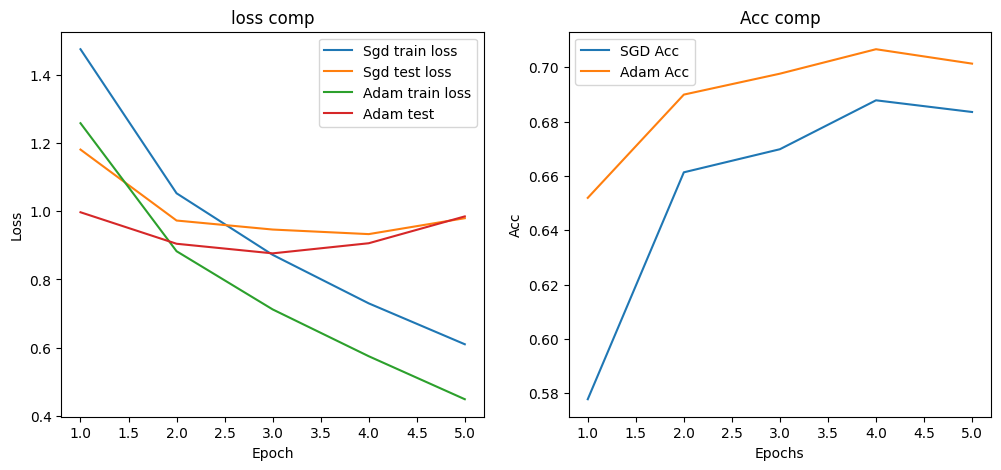

In [21]:
epoch = range(1,6)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epoch, train_s, label='Sgd train loss')
plt.plot(epoch, te_s, label='Sgd test loss')
plt.plot(epoch, train_a, label='Adam train loss')
plt.plot(epoch, te_a, label='Adam test')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('loss comp')

plt.subplot(1,2,2)
plt.plot(epoch, a_s, label='SGD Acc')
plt.plot(epoch, a_a, label='Adam Acc')
plt.title('Acc comp')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Acc')
plt.show()